In [1]:
# Import necessary packages
import torch
from torch import nn
import torchinfo
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import time

# Prepare data loader
from torch.utils.data import Dataset, DataLoader
import h5py
from sklearn.metrics import accuracy_score

In [2]:
# Make sure that CUDA is available - without cuda we would be attempting to run the model on CPU which is tooooo slow. 
assert torch.cuda.is_available(), 'Cuda not available'

In [3]:
class radio_dataset(Dataset):
    all_IQ=[]
    all_mod=[]
    all_snr=[]
    train_sampler:torch.utils.data.SubsetRandomSampler
    val_sampler:torch.utils.data.SubsetRandomSampler
    test_sampler:torch.utils.data.SubsetRandomSampler
    def __init__(self,dataset_path:str,fpmsc:int=4096):
        iq_key="all_IQ_8bit"
        mod_key="all_labels"
        snr_key="all_SNRs"
        
        np.random.seed(2021) #maintain deterministic randomness
        with h5py.File(dataset_path, "r") as h5:
            print(f"Reading dataset: {dataset_path}")
            print(f"All available keys: {list(h5.keys())}")
            self.all_IQ=h5[iq_key][:]
            self.all_mod=h5[mod_key][:].flatten()
            self.all_snr=h5[snr_key][:].flatten()
        print(f"Raw values shape: {self.all_IQ.shape}")
        print(f"Raw values min/max range: {np.min(self.all_IQ)}, {np.max(self.all_IQ)}, {self.all_IQ.dtype}")
        print(f"Labels shape: {self.all_mod.shape}")
        print(f"SNR shape: {self.all_snr.shape}")
        
        train_indices = []
        test_indices = []
        val_indices = []
        # fpmsc: frames per mod snr combination, the dataset is organized as mod major, snr minor
        # each mod-snr-combination has fpsmc frames, we split those fpsmc frames uniformly to train, test, val indices
        for i in range(0,len(self.all_IQ),fpmsc):
            indices_subclass=list(range(i,i+fpmsc))
            split = int(np.ceil(0.8 * fpmsc)) #split 80,10,10
            split2 = int(np.ceil(0.9 * fpmsc))
            
            np.random.shuffle(indices_subclass)
            
            train_indices_subclass = indices_subclass[:split]
            val_indices_subclass = indices_subclass[split:split2]
            test_indices_subclass = indices_subclass[split2:]
            
            train_indices.extend(train_indices_subclass)
            test_indices.extend(test_indices_subclass)
            val_indices.extend(val_indices_subclass) 
        
        self.train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
        self.val_sampler = torch.utils.data.SubsetRandomSampler(val_indices)
        self.test_sampler = torch.utils.data.SubsetRandomSampler(test_indices)
        
        print('Training set size: ',len(self.train_sampler))
        print('Val set size: ',len(self.val_sampler))
        print('Test set size: ',len(self.test_sampler))
    
    def __getitem__(self, idx):
        # transpose frame into Pytorch channels-first format (NCL = -1,2,1024)
        return self.all_IQ[idx].transpose(), self.all_mod[idx], self.all_snr[idx]

In [4]:
import brevitas.nn as qnn
from brevitas.quant import Int8Bias
from brevitas.inject.enum import ScalingImplType
from brevitas.inject.defaults import Int8ActPerTensorFloatMinMaxInit

def quantized_vgg10(model_body_bit:int)->nn.Sequential:
    a_bits = model_body_bit  # a_bits is the bit width for ReLu
    w_bits = model_body_bit # w_bits is the bit width for all the weights
    
    input_bits:int=8
    new_min=-128.0
    new_max=128
    filters_conv = 64
    filters_dense = 128
    
    class InputQuantizer(Int8ActPerTensorFloatMinMaxInit):
        #Quantize to input_bits
        bit_width = input_bits
        
        #Min max value of the input. Set to the range value of the input 
        min_val = new_min #the min value of the input(dataset) before going through the model
        max_val = new_max #the max value of the input(dataset) before going through the model
        scaling_impl_type = ScalingImplType.CONST # Fix the quantization range to [min_val, max_val]
    
    return nn.Sequential(
            # Input quantization layer
            qnn.QuantHardTanh(act_quant=InputQuantizer),
        
            qnn.QuantConv1d(2, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits,bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
            
            nn.Flatten(),
        
            qnn.QuantLinear(filters_conv*8, filters_dense, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_dense),
            qnn.QuantReLU(bit_width=a_bits),
        
            qnn.QuantLinear(filters_dense, filters_dense, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_dense),
            qnn.QuantReLU(bit_width=a_bits, return_quant_tensor=True),
        
            qnn.QuantLinear(filters_dense, 15, weight_bit_width=w_bits, bias=True, bias_quant=Int8Bias),
        )
# print(torchinfo.summary(model,input_size=(1,2,1024),depth=1));

In [5]:
class testing_result():
    y_pred=[]
    y_exp=[]
    y_snr=[]
    def __init__(self,pred,exp,snr):
        self.y_pred=pred
        self.y_exp=exp
        self.y_snr=snr

def testing_model(model_path:str, model_bit_width:int, dataset_path:str, batch_size:int=1024)->testing_result:   
    model=quantized_vgg10(model_bit_width)
    model.load_state_dict(torch.load(model_path))
    model.to('cuda')
    # print(torchinfo.summary(model,input_size=(1,2,1024),depth=1));
    
    dataset=radio_dataset(dataset_path, 4096)
    test_dataset=DataLoader(dataset, batch_size=batch_size, sampler=dataset.test_sampler)
    y_pred = np.empty((0)) 
    y_exp = np.empty((0))
    y_snr = np.empty((0))
    model.eval()

    with torch.no_grad():
        for data in tqdm(test_dataset, desc="Batches"):
            inputs, target, snr = data
            inputs = inputs.to('cuda').float()
            output = model(inputs).cpu()
            #model raw output 15 mods prediction values, we can do the softmax here
            output = np.argmax(output,axis=1)
            y_pred = np.concatenate((y_pred,output))
            y_exp = np.concatenate((y_exp,target))
            y_snr = np.concatenate((y_snr,snr))

    return testing_result(y_pred,y_exp,y_snr)

In [6]:
def plot_confusion_matrix(cm,labels=[], title="", cmap=plt.cm.Blues, plot_dir="", use_save=False, threshold=0.01):
    plt.figure(figsize=(12,8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=90)
    plt.yticks(tick_marks, labels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i,j]>threshold: #threshold to show on plot
                plt.text(j, i, f"{cm[i, j]:.2f}", 
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
                
    # plt.plot(np.arange(cm.shape[0]), np.arange(cm.shape[1]), 
    #          color='red', linestyle='--', linewidth=1.5, alpha=0.25)

    plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5, alpha=0.25)
    if use_save:
        plt.savefig(f'{plot_dir}/{title.lower().replace(" ","_")}', bbox_inches='tight',format='jpeg')
    plt.show()

def get_cm(test_result:testing_result, label_count:int, normalized:bool=True, filter_snr=None):
    
    conf = np.zeros([label_count,label_count])
    confnorm = np.zeros([label_count,label_count])

    ye=test_result.y_exp
    yp=test_result.y_pred
    ysnr=test_result.y_snr
    #raw confusion mat
    for i in range(len(ye)):
        if (filter_snr is not None) and (ysnr[i] not in filter_snr):
            continue
        e = int(ye[i]) #index label of expected -> major axis / y axis
        p = int((yp[i])) #index label of prediction -> minor axis / x axis
        conf[e,p] = conf[e,p] + 1

    if (not normalized):
        return conf
    
    #norm confusion mat
    for i in range(label_count): #go from top down, divide all cells in each row by the sum of each row to normalize. all cells each row should sum up to 1
        row_sum=np.sum(conf[i,:])
        if row_sum>0.0:
            confnorm[i,:] = conf[i,:] / row_sum
        else:
            confnorm[i,:] = 0.0
            
    return confnorm

In [100]:
def get_acc_breakdown_over_snr(test_result:testing_result, label_count:int):
    snr_list=np.unique(test_result.y_snr)
    
    correct=np.zeros([len(snr_list),label_count])
    total=np.zeros([len(snr_list),label_count])
    index:int=0
    for s in snr_list:
        conf=get_cm(test_result, label_count, normalized=False, filter_snr=[s])
        for m in range(label_count):
            correct[index,m]=conf[m,m]
            total[index,m]=np.sum(np.sum(conf[m,:]))
        index+=1
    return correct,total

def graph_multiline(data, x_data, x_label, legends=None, title="", xlabel="SNR(dB)", ylabel="Acc."):
    fntsize=16
    markers = ['o', 's', '^', 'd', 'v', 'p', '*']
    plt.figure(figsize=(12,8))
    # plt.plot(x_data,data)
    for i, y in enumerate(np.array(data).T):
        plt.plot(x_data, y, marker=markers[i % len(markers)], markersize=10)
    
    plt.grid(True)
    if legends is not None:
        plt.legend(legends, loc='lower right', bbox_to_anchor=(1.0,0.0),fontsize=fntsize)
    plt.title(title,fontsize=fntsize)
    plt.xticks(x_label,fontsize=fntsize)
    # plt.setxticks(np.arange(0,31.0,5.0))
    # plt.axes.set_xticks(np.arange(0,31.0,5.0))
    plt.yticks(np.arange(0, 1.1, 0.1),fontsize=fntsize)
    plt.tight_layout()
    plt.xlabel(xlabel,fontsize=fntsize*1.25)
    plt.ylabel(ylabel,fontsize=fntsize*1.25)
    plt.show()

## Example Usage

Reading dataset: datasets/MatGenData_ppm0_rician_int8_20260213.h5
All available keys: ['all_IQ_8bit', 'all_SNRs', 'all_labels']
Raw values shape: (983040, 1024, 2)
Raw values min/max range: -128, 127, int8
Labels shape: (983040,)
SNR shape: (983040,)
Training set size:  786480
Val set size:  98400
Test set size:  98160


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

Reading dataset: datasets/MatGenData_ppm0_rician_int8_20260213.h5
All available keys: ['all_IQ_8bit', 'all_SNRs', 'all_labels']
Raw values shape: (983040, 1024, 2)
Raw values min/max range: -128, 127, int8
Labels shape: (983040,)
SNR shape: (983040,)
Training set size:  786480
Val set size:  98400
Test set size:  98160


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

Reading dataset: datasets/MatGenData_ppm0_rician_int8_20260213.h5
All available keys: ['all_IQ_8bit', 'all_SNRs', 'all_labels']
Raw values shape: (983040, 1024, 2)
Raw values min/max range: -128, 127, int8
Labels shape: (983040,)
SNR shape: (983040,)
Training set size:  786480
Val set size:  98400
Test set size:  98160


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

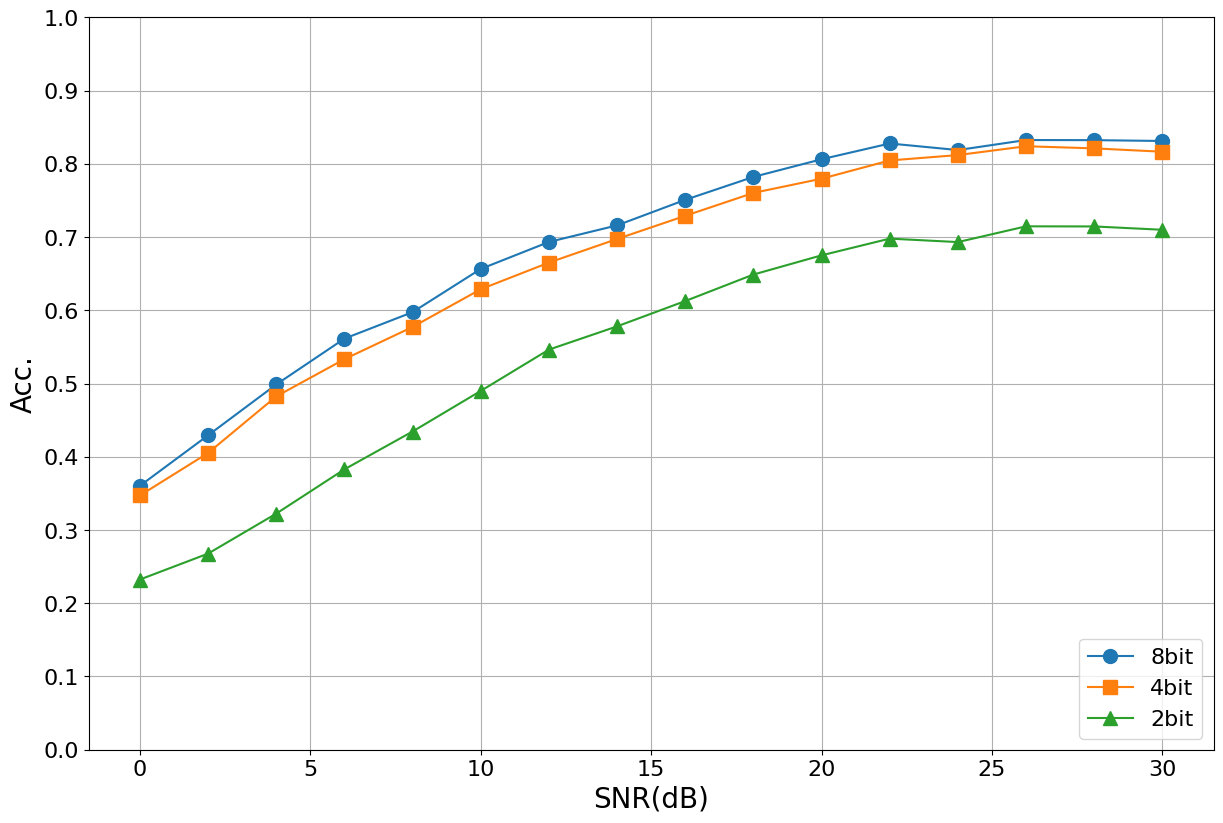

In [101]:
def example():
    mod_classes = ["BPSK", 
                    "QPSK", 
                    "8PSK",
                    "16QAM",
                    "32QAM", 
                    "64QAM", 
                    "128QAM", 
                    "256QAM",
                    "16APSK", 
                    "32APSK", 
                    "64APSK", 
                    "128APSK",
                    "FM", 
                    "AM-DSB-SC", 
                    "AM-SSB-SC"]

    lbl_count:int=len(mod_classes)
    snr_list=np.arange(0.0,31.0,2.0)
    
    test_rician_on_rician=testing_model("testing_rician_ppm0/model_brevitas.pth",8,"datasets/MatGenData_ppm0_rician_int8_20260213.h5")
    # conf=get_cm(test_rician_on_rician, lbl_count, normalized=True, filter_snr=[10.0])
    # plot_confusion_matrix(conf, labels=mod_classes, threshold=0.2, title="Confusion Matrix of 8bit Model (train: Rician PPM0 | test: Rician PPM0)")

    correct_over_snr, total_over_snr= get_acc_breakdown_over_snr(test_rician_on_rician, label_count=lbl_count)

    snr_x_ticks=np.arange(0.0,31.0,2.0)
    # acc_brkdown=correct_over_snr/total_over_snr
    # graph_multiline(acc_brkdown,snr_x_ticks, mod_classes, title="Accuracy Breakdown of 8bit Model (train:Rician PPM0 | test: RicianPPM0)")

    acc_over_snr=np.sum(correct_over_snr,axis=1)/np.sum(total_over_snr,axis=1)
    # graph_multiline(acc_over_snr,snr_x_ticks, None,title="Accuracy Breakdown of 8bit Model (train:Rician PPM0 | test: RicianPPM0)")

    test_rician_on_rician_4bit=testing_model("archive/rician_matgen_ppm0_2026_feb13_report/4bit/model_brevitas.pth",4,"datasets/MatGenData_ppm0_rician_int8_20260213.h5")
    correct_over_snr1, total_over_snr1= get_acc_breakdown_over_snr(test_rician_on_rician_4bit, label_count=lbl_count)
    acc_over_snr1=np.sum(correct_over_snr1,axis=1)/np.sum(total_over_snr1,axis=1)

    test_rician_on_rician_2bit=testing_model("archive/rician_matgen_ppm0_2026_feb13_report/2bit/model_brevitas.pth",2,"datasets/MatGenData_ppm0_rician_int8_20260213.h5")
    correct_over_snr2, total_over_snr2= get_acc_breakdown_over_snr(test_rician_on_rician_2bit, label_count=lbl_count)
    acc_over_snr2=np.sum(correct_over_snr2,axis=1)/np.sum(total_over_snr2,axis=1)
    
    graph_multiline(np.array([acc_over_snr,acc_over_snr1,acc_over_snr2]).transpose(),x_data=snr_x_ticks, x_label=np.arange(0.0,31.0,5.0), legends=["8bit","4bit","2bit"],title="")
example()